# 第067讲 Gaussian过程回归

这是可顺序重跑的完整实验。请在本讲目录打开Notebook。所有数据原创合成，输出写入outputs/notebook，保留冻结参考报告。先读问题与公式，再观察实际数值；不要根据测试结果追加候选后仍称其为封存评估。

In [1]:
# 环境与依赖版本。没有任何网络下载。
import json, sys, subprocess
from pathlib import Path
import numpy as np
import scipy, sklearn, pandas as pd
from IPython.display import display, Image
from common import load_data, safe_output, write_json
print({'python': sys.version.split()[0], 'numpy': np.__version__, 'scipy': scipy.__version__, 'sklearn': sklearn.__version__})
data = load_data()
print({name: len(part['id']) for name, part in data.items()})

{'python': '3.12.14', 'numpy': '2.3.5', 'scipy': '1.17.0', 'sklearn': '1.8.0'}
{'train': 12, 'interpolation': 121, 'extrapolation': 121}


## 1 二点条件分布
先手算C的行列式21/16，再核对系数4/3与-4/3。中点两侧信息抵消后均值为零，但潜在方差不是零。测量预测还需加独立物理噪声。

In [2]:
from gaussian_process import kernel, fit, predict
X = np.array([[-1.], [1.]])
y = np.array([1., -1.])
ell = np.sqrt(2 / np.log(2))
model = fit(X, y, length_scale=ell, noise_variance=.25, jitter=0.)
mu, covariance = predict(model, [[0.]])
mu_y, covariance_y = predict(model, [[0.]], observation=True)
print('C =', model['C'])
print('coefficients =', model['a'])
print('latent mean and variance =', mu, covariance)
print('observation variance =', covariance_y)
print('LML terms and total =', model['lml_parts'], model['lml'])

C = [[1.25 0.5 ]
 [0.5  1.25]]
coefficients = [ 1.33333333 -1.33333333]
latent mean and variance = [2.69107448e-17] [[0.19187796]]
observation variance = [[0.44187796]]
LML terms and total = [-1.333333333333333, -0.13596685774182102, -1.8378770664093453] -3.3071772574844993


## 2 库对照先固定所有约定
禁止优化核参数，不归一化目标。alpha这里代表训练噪声方差。返回的是RBF潜在过程的协方差。

In [3]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
gp = GaussianProcessRegressor(kernel=RBF(ell, length_scale_bounds='fixed'), alpha=.25, optimizer=None, normalize_y=False).fit(X, y)
lib_mu, lib_cov = gp.predict([[0.]], return_cov=True)
print('sklearn mean and covariance =', lib_mu, lib_cov)
print('absolute differences =', abs(mu-lib_mu), abs(covariance-lib_cov))
print('sklearn LML =', gp.log_marginal_likelihood())

sklearn mean and covariance = [2.69107448e-17] [[0.19187796]]
absolute differences = [0.] [[0.]]
sklearn LML = -3.3071772574844993


## 3 真正执行五组机制实验
训练12条，插值和外推各121条。f_true只用于评估。241个查询点上的完整均值与协方差和库逐项比较。

In [4]:
from experiment import run
report = run()
write_json(safe_output('outputs/notebook/result.json'), report)
rows=[]
for row in report['variants']:
    rows.append({'setting':row['label'], 'length':row['length_scale'], 'noise_variance':row['noise_variance'], 'interpolation_rmse':row['interpolation']['latent_rmse'], 'extrapolation_rmse':row['extrapolation']['latent_rmse'], 'extrapolation_grid_fraction':row['extrapolation']['latent_pointwise_95_fraction'], 'LML':row['lml']})
display(pd.DataFrame(rows))
print('Maximum full-library errors:', report['library_max_errors'])

,setting,length,noise_variance,interpolation_rmse,extrapolation_rmse,extrapolation_grid_fraction,LML
0,short length,0.25,0.0324,0.162300,1.199551,0.851240,-14.142059
1,reference,1.00,0.0324,0.086978,1.224291,0.842975,-6.813290
2,long length,3.00,0.0324,0.314898,2.810465,0.173554,-39.093438
3,too little noise,1.00,0.0001,0.244934,2.222946,0.421488,-420.813886
4,large noise,1.00,0.3600,0.132132,1.221696,0.842975,-11.616525


Maximum full-library errors: {'mean': 1.1624479157035239e-11, 'covariance': 1.1468603844377867e-13, 'lml': 5.941842573520262e-10}


## 4 alpha WhiteKernel 与jitter
观察同一训练矩阵产生相同均值，但预测对角是否包含物理噪声不同。重复输入的奇异失败路径已实际执行，不是预写的假想结果。

In [5]:
print('Noise API comparison:', report['noise_api'])
print('Singular matrix experiment:', report['jitter_check'])
print('Optimized length and LML:', report['optimized']['length_scale'], report['optimized']['lml'])
display(pd.DataFrame(report['cost']))

Noise API comparison: {'max_mean_difference': 0.0, 'min_variance_difference': 0.03239999999999987, 'max_variance_difference': 0.032400000000000095, 'expected_added_noise_variance': 0.0324}
Singular matrix experiment: {'singular_without_jitter_failed': True, 'jitter': 1e-10, 'condition_number': 24928533135.536114, 'finite_coefficients': True}
Optimized length and LML: 1.2824275185144478 -6.162364044489748


,n,one_dense_matrix_bytes,cholesky_leading_flops
0,100,80000,3.333333e+05
1,1000,8000000,3.333333e+08
2,10000,800000000,3.333333e+11
3,100000,80000000000,3.333333e+14


## 5 固定超参数的一个反直觉检查
把训练y全部取反，均值也取反，但后验协方差保持不变。方差由输入几何、核与噪声假设决定，不是万能的异常识别器。

In [6]:
part=data['train']; Xtrain=part['x'][:,None]; ytrain=part['y']
a=fit(Xtrain, ytrain); b=fit(Xtrain, -ytrain)
ma,ca=predict(a, [[0.],[4.]]); mb,cb=predict(b, [[0.],[4.]])
print('Mean sign check:', np.max(abs(ma+mb)))
print('Covariance invariance:', np.max(abs(ca-cb)))

Mean sign check: 0.0
Covariance invariance: 0.0


## 显式验收
以下启动两个真正的新Python进程，分别运行普通与-O模式。任何失败都会让Notebook停止，代码没有用assert充当唯一验证。

In [7]:
for optimize in [False, True]:
    mode = ['-O'] if optimize else []
    destination = 'outputs/notebook/tests-O.json' if optimize else 'outputs/notebook/tests.json'
    proc = subprocess.run([sys.executable, *mode, 'test_experiment.py', '--report', 'outputs/notebook/result.json', '--out', destination], capture_output=True, text=True, check=True)
    print(proc.stdout.strip())

{"status": "passed", "checks": 95, "python_optimized": false}


{"status": "passed", "checks": 95, "python_optimized": true}


## 解释图
每张图重新从刚生成的report制作，并作为PNG嵌入Notebook。图的中文读法在讲义对应图注；英文坐标使图的重建不依赖中文绘图字体。

In [8]:
from plots import make
figure_paths = make(report, Path('outputs/notebook/figures'))
print('Generated figure count:', len(figure_paths))

Generated figure count: 7


### 图 1 01_prior_samples
先说出横轴、纵轴和保持不变的条件，再描述曲线变化。不要把阴影、误差线或背景色自动理解为经过独立验证的概率保证。

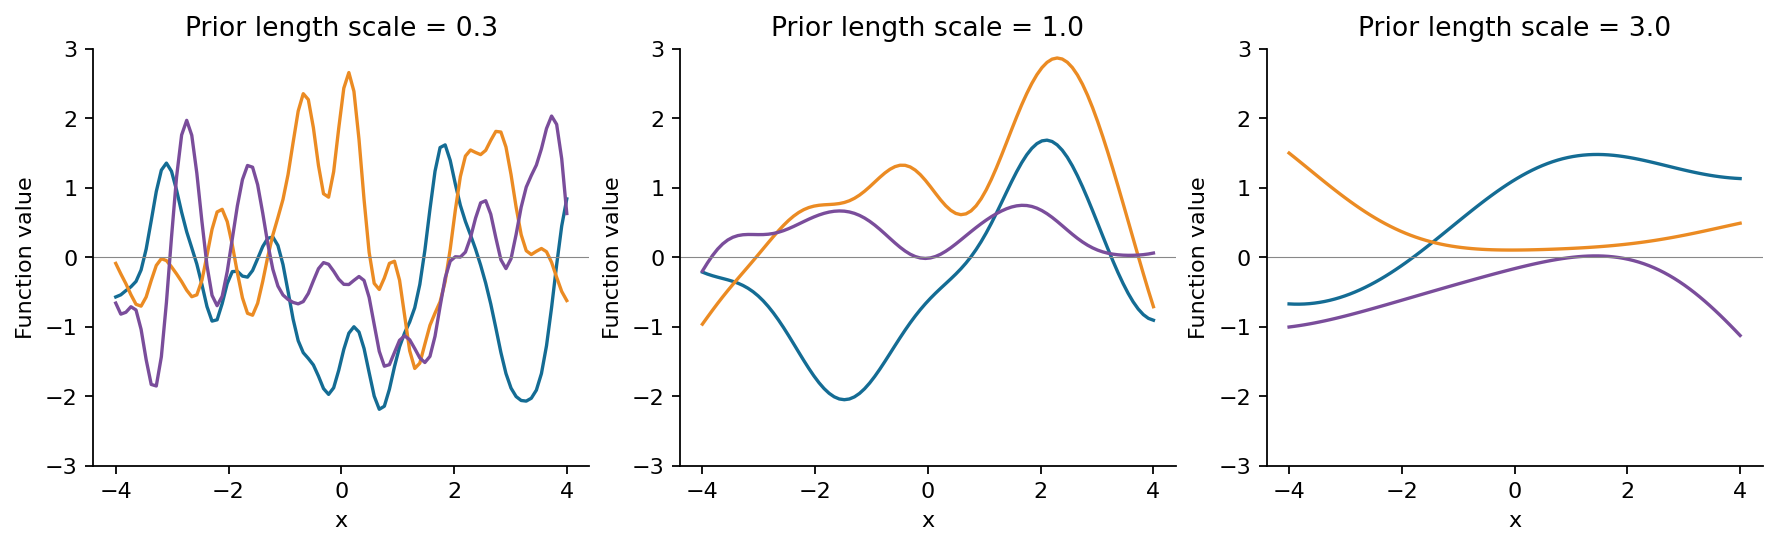

In [9]:
display(Image(filename=str(figure_paths[0])))

### 图 2 02_posterior_bands
先说出横轴、纵轴和保持不变的条件，再描述曲线变化。不要把阴影、误差线或背景色自动理解为经过独立验证的概率保证。

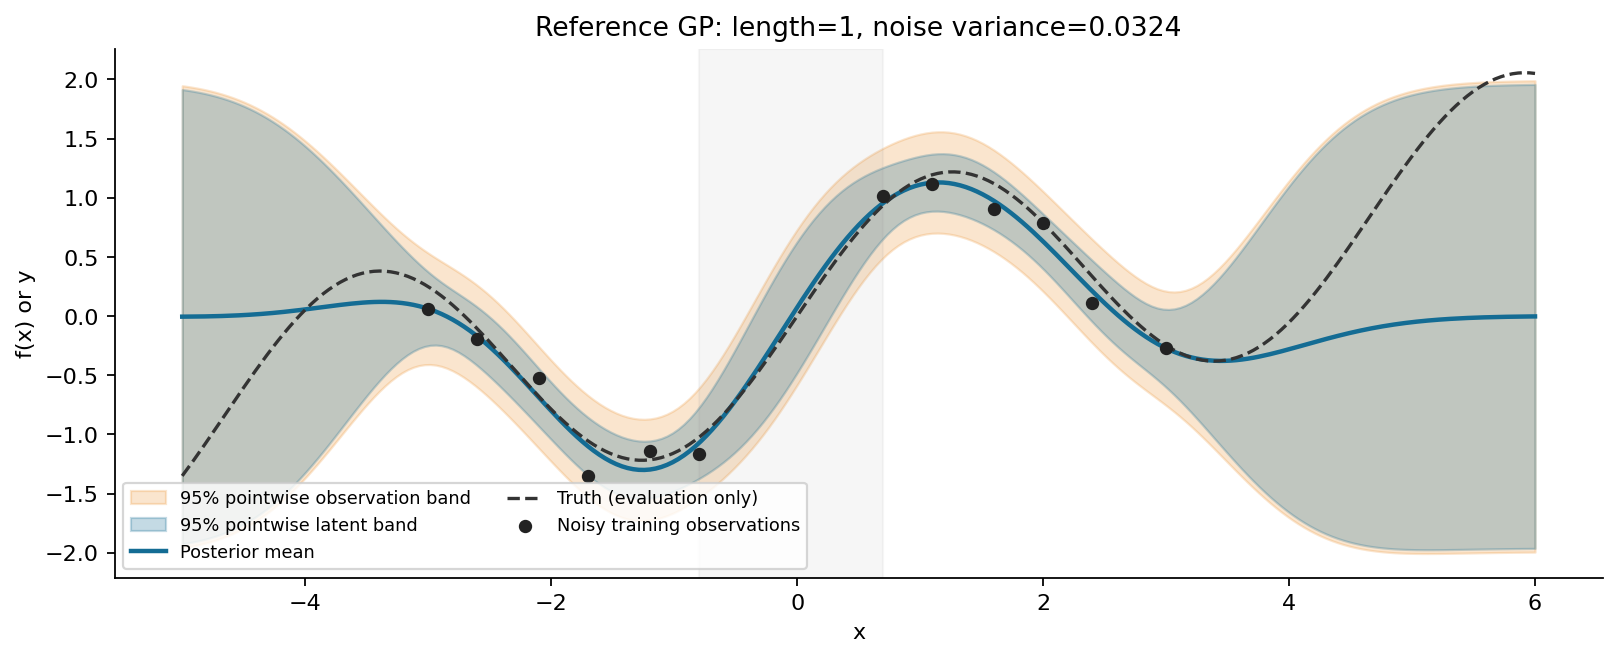

In [10]:
display(Image(filename=str(figure_paths[1])))

### 图 3 03_length_scale
先说出横轴、纵轴和保持不变的条件，再描述曲线变化。不要把阴影、误差线或背景色自动理解为经过独立验证的概率保证。

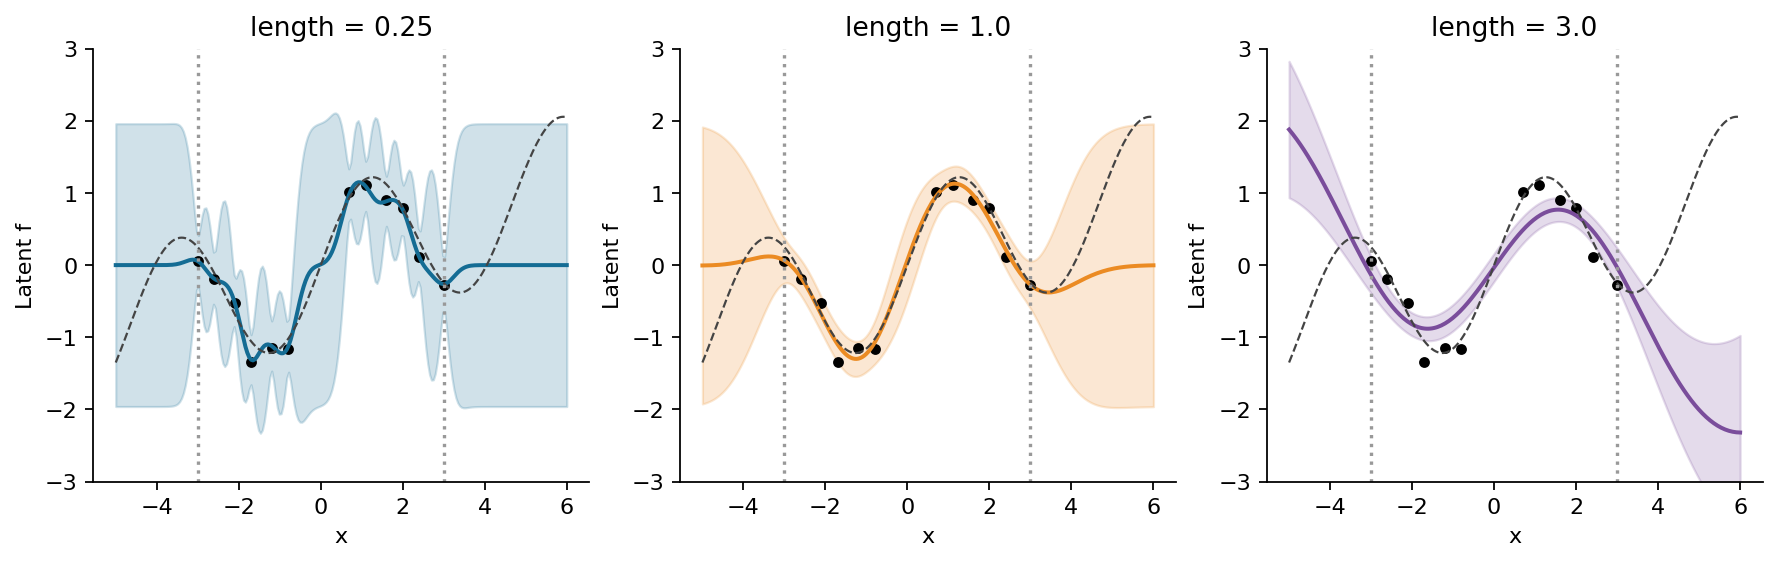

In [11]:
display(Image(filename=str(figure_paths[2])))

### 图 4 04_noise_assumptions
先说出横轴、纵轴和保持不变的条件，再描述曲线变化。不要把阴影、误差线或背景色自动理解为经过独立验证的概率保证。

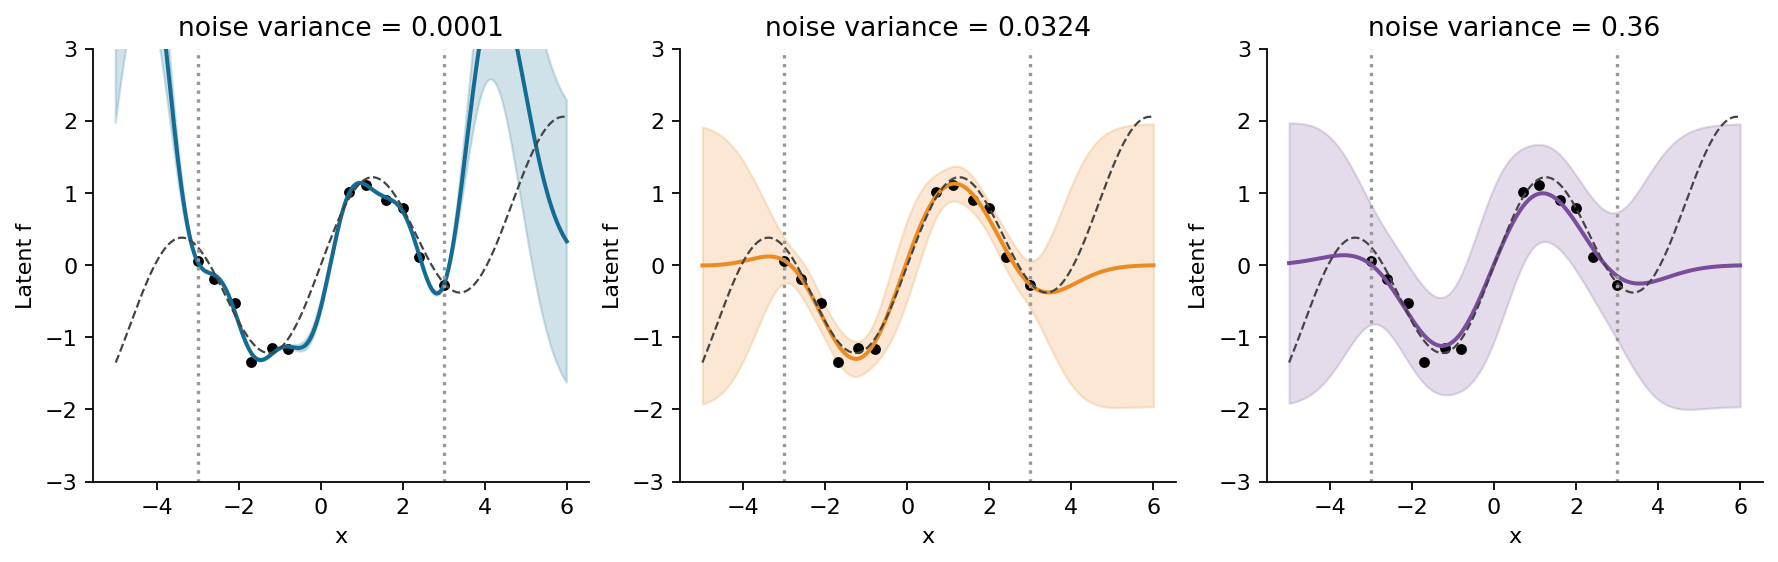

In [12]:
display(Image(filename=str(figure_paths[3])))

### 图 5 05_marginal_likelihood
先说出横轴、纵轴和保持不变的条件，再描述曲线变化。不要把阴影、误差线或背景色自动理解为经过独立验证的概率保证。

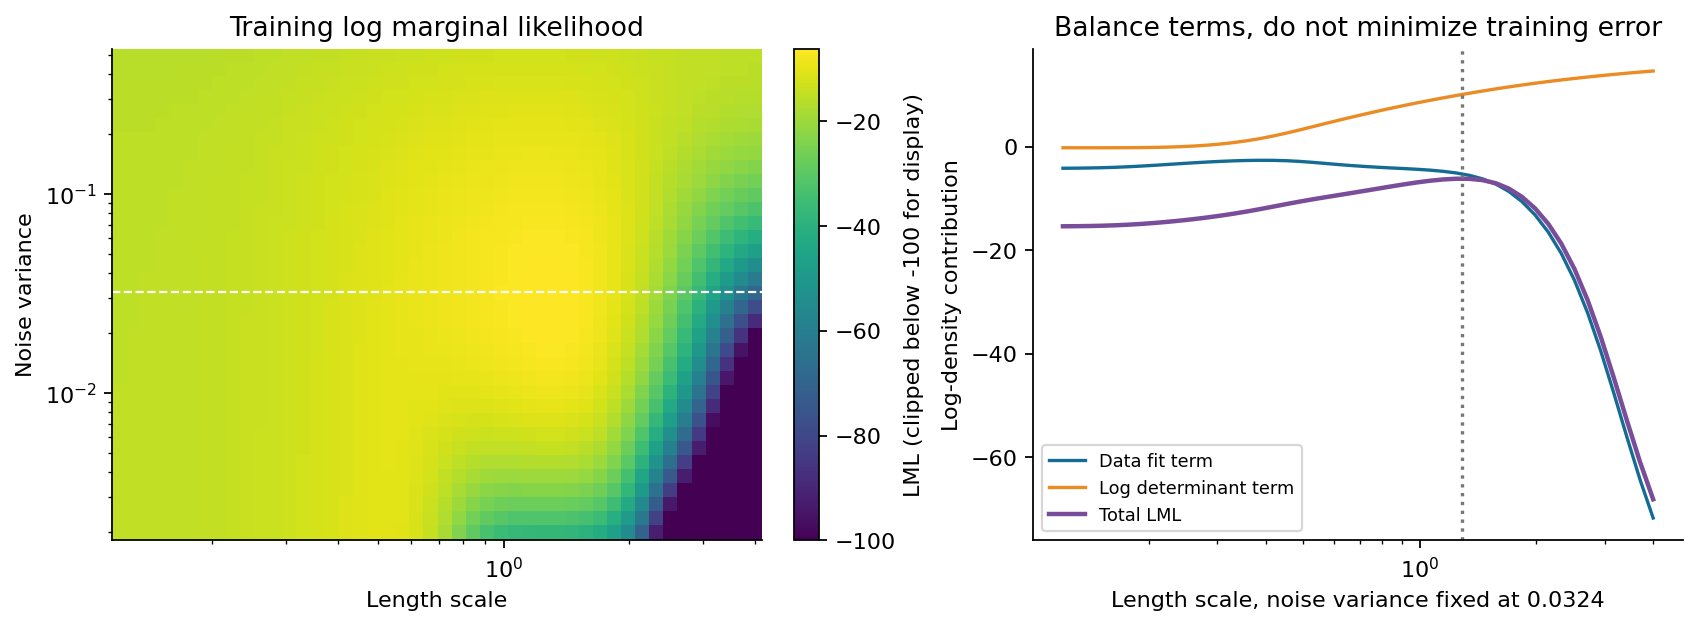

In [13]:
display(Image(filename=str(figure_paths[4])))

### 图 6 06_extrapolation_audit
先说出横轴、纵轴和保持不变的条件，再描述曲线变化。不要把阴影、误差线或背景色自动理解为经过独立验证的概率保证。

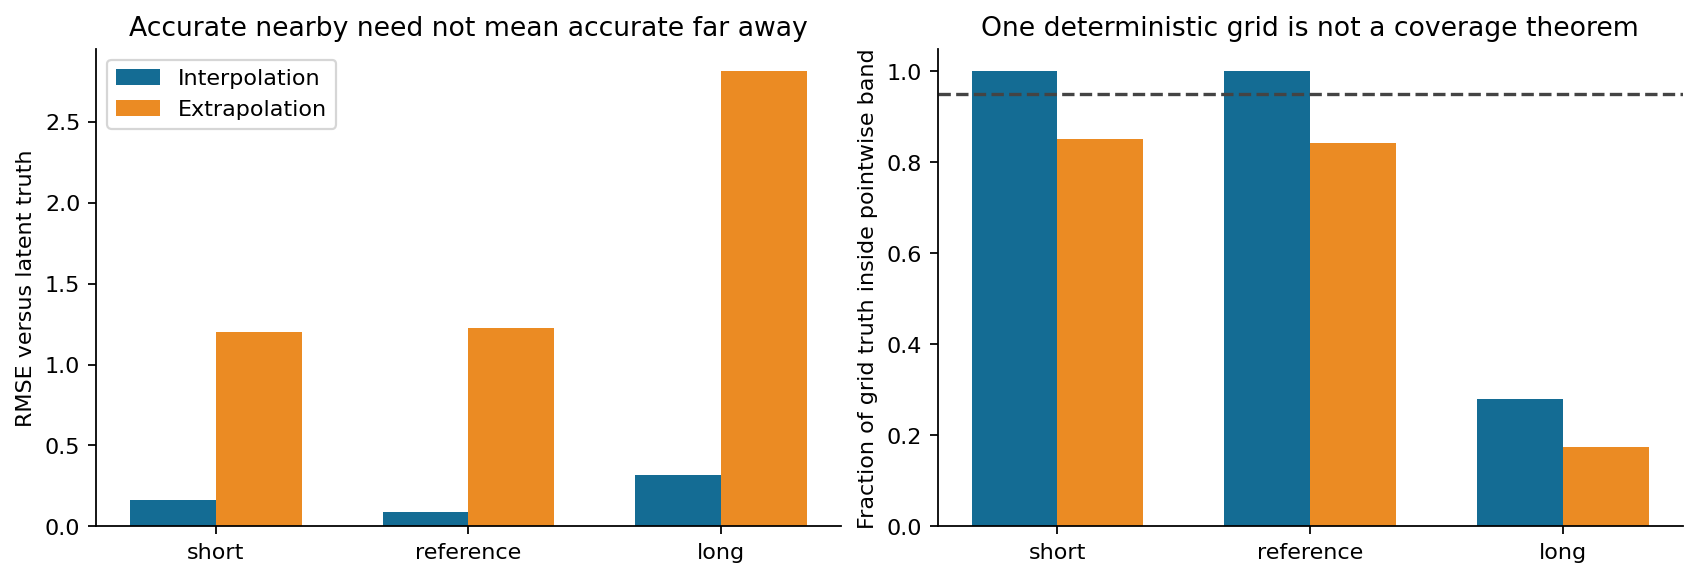

In [14]:
display(Image(filename=str(figure_paths[5])))

### 图 7 07_dense_cost
先说出横轴、纵轴和保持不变的条件，再描述曲线变化。不要把阴影、误差线或背景色自动理解为经过独立验证的概率保证。

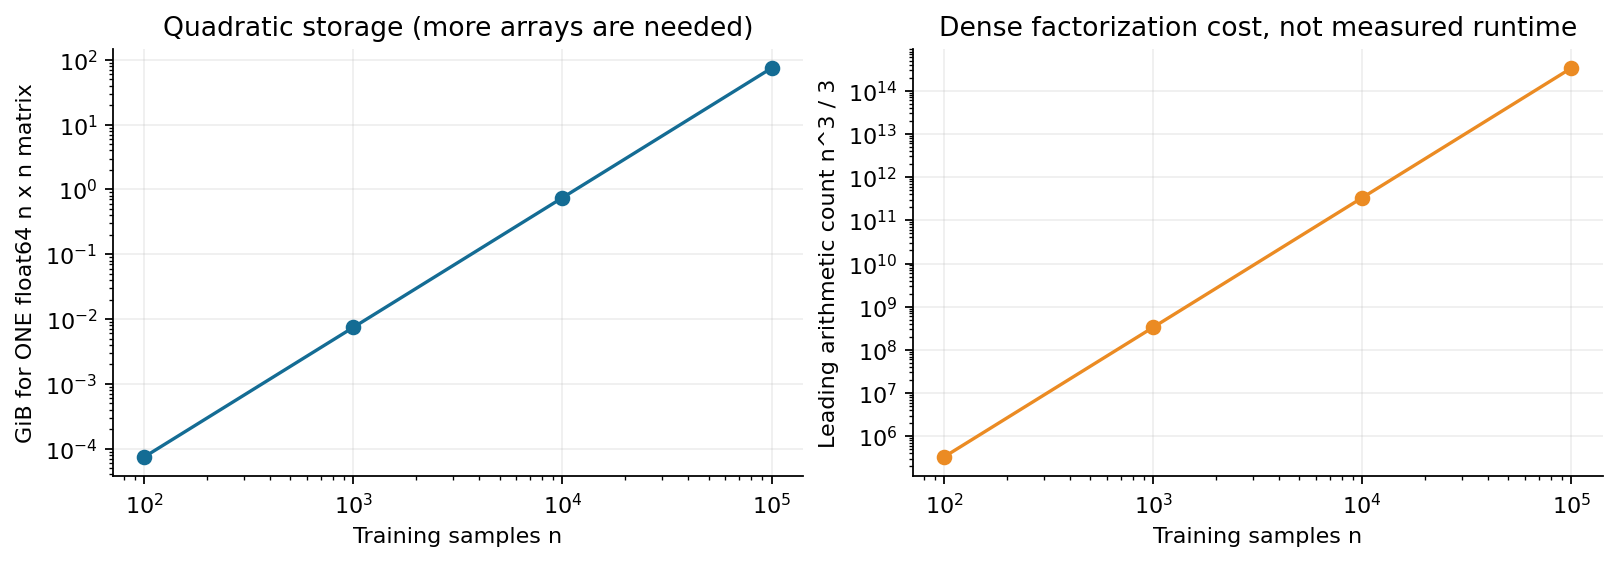

In [15]:
display(Image(filename=str(figure_paths[6])))

## 完成后的判断
1. 写出一个从数值证据支持的结论。
2. 写出一个当前实验尚未支持的外推。
3. 说明若要扩大数据规模，你会先测量哪种资源。

修改参数或数据时使用新的实验目录与预先规定的评估协议，不要覆盖冻结参考结果后仍沿用原验收结论。